##EXP-12
Implement L1 (Lasso) and L2 (Ridge) regularization on the given Melbourne
House Price Dataset. (Prepare Viva question on overfitting, underfitting and
regularization)

##Importing libraries and loading dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from scipy.special import expit
df = pd.read_csv('/content/drive/MyDrive/AML_Lab_B19/Exp-12 Melbourne House Price Dataset/dataset_Melbourne_housing_FULL_exp_12.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (34857, 21)
       Suburb             Address  Rooms Type      Price Method SellerG  \
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis   
1  Abbotsford        85 Turner St      2    h  1480000.0      S  Biggin   
2  Abbotsford     25 Bloomburg St      2    h  1035000.0      S  Biggin   
3  Abbotsford  18/659 Victoria St      3    u        NaN     VB  Rounds   
4  Abbotsford        5 Charles St      3    h  1465000.0     SP  Biggin   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/09/2016       2.5    3067.0  ...       1.0  1.0     126.0           NaN   
1  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
2  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
3  4/02/2016       2.5    3067.0  ...       2.0  1.0       0.0           NaN   
4  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   

   YearBuilt         CouncilArea Lattitud

##Data preprocessing - Handle missing values and encode categoricals

In [2]:
# Drop rows with missing Price
df = df.dropna(subset=['Price'])

# Fill missing numerical with median
num_cols = ['Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'Postcode']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical
df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])
df['Regionname'] = df['Regionname'].fillna(df['Regionname'].mode()[0])

# Encode categorical variables
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])
df['Regionname_encoded'] = le.fit_transform(df['Regionname'])
df['CouncilArea_encoded'] = le.fit_transform(df['CouncilArea'])

# Select features (drop non-numeric and target)
drop_cols = ['Suburb', 'Address', 'Method', 'SellerG', 'Date', 'Price', 'Type', 'Regionname', 'CouncilArea']
X = df.drop(drop_cols, axis=1)
y = df['Price']

print(f"Features shape: {X.shape}")
print(X.head())

Features shape: (27247, 15)
   Rooms  Distance  Postcode  Bedroom2  Bathroom  Car  Landsize  BuildingArea  \
1      2       2.5    3067.0       2.0       1.0  1.0     202.0         133.0   
2      2       2.5    3067.0       2.0       1.0  0.0     156.0          79.0   
4      3       2.5    3067.0       3.0       2.0  0.0     134.0         150.0   
5      3       2.5    3067.0       3.0       2.0  1.0      94.0         133.0   
6      4       2.5    3067.0       3.0       1.0  2.0     120.0         142.0   

   YearBuilt  Lattitude  Longtitude  Propertycount  Type_encoded  \
1     1970.0   -37.7996    144.9984         4019.0             0   
2     1900.0   -37.8079    144.9934         4019.0             0   
4     1900.0   -37.8093    144.9944         4019.0             0   
5     1970.0   -37.7969    144.9969         4019.0             0   
6     2014.0   -37.8072    144.9941         4019.0             0   

   Regionname_encoded  CouncilArea_encoded  
1                   2          

##Train-test split and scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (21797, 15)
Test set shape: (5450, 15)


## Train Linear Regression (baseline), Lasso, and Ridge

In [4]:
# Linear Regression (no regularization)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Lasso (L1)
lasso = Lasso(alpha=1000, random_state=42)  # alpha for regularization strength
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_coefs = np.sum(lasso.coef_ != 0)

# Ridge (L2)
ridge = Ridge(alpha=1000, random_state=42)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Linear RMSE: {lr_rmse:.2f}, R2: {lr_r2:.3f}")
print(f"Lasso RMSE: {lasso_rmse:.2f}, R2: {lasso_r2:.3f}, Non-zero coefs: {lasso_coefs}")
print(f"Ridge RMSE: {ridge_rmse:.2f}, R2: {ridge_r2:.3f}")

Linear RMSE: 465583.11, R2: 0.493
Lasso RMSE: 465216.36, R2: 0.494, Non-zero coefs: 15
Ridge RMSE: 466032.01, R2: 0.492


##Hyperparameter tuning with GridSearchCV for optimal alpha

In [5]:
# Lasso tuning
lasso_params = {'alpha': np.logspace(-4, 4, 20)}
lasso_gs = GridSearchCV(Lasso(random_state=42), lasso_params, cv=5, scoring='r2')
lasso_gs.fit(X_train_scaled, y_train)
best_lasso = lasso_gs.best_estimator_
best_lasso_pred = best_lasso.predict(X_test_scaled)
best_lasso_rmse = np.sqrt(mean_squared_error(y_test, best_lasso_pred))
best_lasso_r2 = r2_score(y_test, best_lasso_pred)
print(f"Best Lasso alpha: {lasso_gs.best_params_}, RMSE: {best_lasso_rmse:.2f}, R2: {best_lasso_r2:.3f}")

# Ridge tuning
ridge_params = {'alpha': np.logspace(-4, 4, 20)}
ridge_gs = GridSearchCV(Ridge(random_state=42), ridge_params, cv=5, scoring='r2')
ridge_gs.fit(X_train_scaled, y_train)
best_ridge = ridge_gs.best_estimator_
best_ridge_pred = best_ridge.predict(X_test_scaled)
best_ridge_rmse = np.sqrt(mean_squared_error(y_test, best_ridge_pred))
best_ridge_r2 = r2_score(y_test, best_ridge_pred)
print(f"Best Ridge alpha: {ridge_gs.best_params_}, RMSE: {best_ridge_rmse:.2f}, R2: {best_ridge_r2:.3f}")


Best Lasso alpha: {'alpha': np.float64(10000.0)}, RMSE: 463634.28, R2: 0.497
Best Ridge alpha: {'alpha': np.float64(3792.690190732246)}, RMSE: 471026.63, R2: 0.481


##ROC and AUC curves (using probability-like predictions via sigmoid)

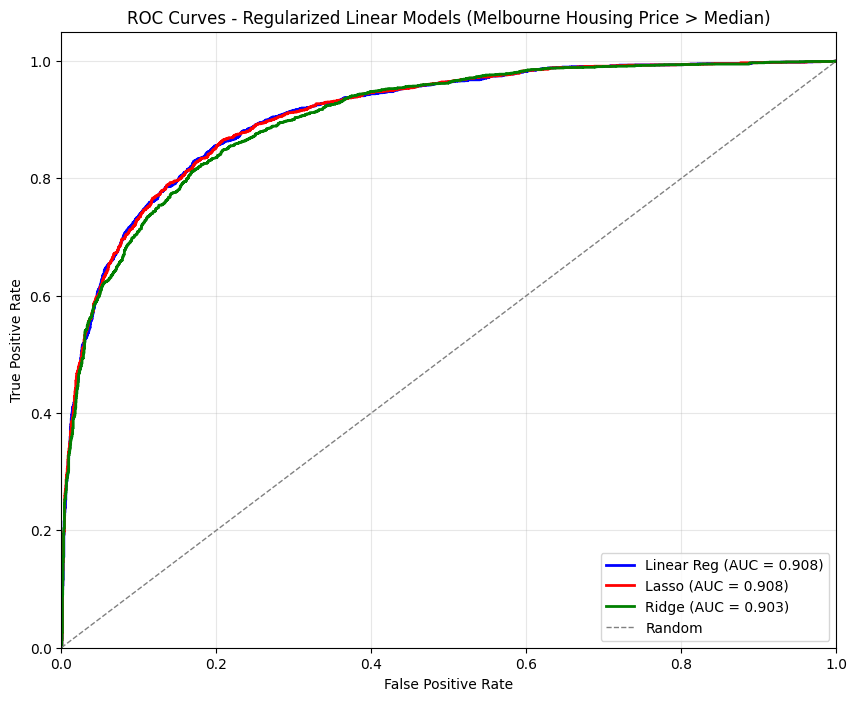

ROC and AUC plot saved successfully to output/roc_auc_curves.png
AUC Scores - Linear: 0.908, Lasso: 0.908, Ridge: 0.903


In [6]:
import os
os.makedirs('output', exist_ok=True)

# Convert predictions to probability-like scores using sigmoid
def get_probs(model, X):
    preds = model.predict(X)
    return expit((preds - preds.mean()) / preds.std())  # Normalize to [0,1]

# Create binary target for ROC (price above median)
y_train_bin = (y_train > y_train.median()).astype(int)
y_test_bin = (y_test > y_test.median()).astype(int)

# Get probabilities for tuned models
lasso_probs_test = get_probs(best_lasso, X_test_scaled)
ridge_probs_test = get_probs(best_ridge, X_test_scaled)
lr_probs_test = get_probs(lr, X_test_scaled)

# Compute ROC curves
fpr_lasso, tpr_lasso, _ = roc_curve(y_test_bin, lasso_probs_test)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)

fpr_ridge, tpr_ridge, _ = roc_curve(y_test_bin, ridge_probs_test)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)

fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, lr_probs_test)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Linear Reg (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_lasso, tpr_lasso, color='red', lw=2, label=f'Lasso (AUC = {roc_auc_lasso:.3f})')
plt.plot(fpr_ridge, tpr_ridge, color='green', lw=2, label=f'Ridge (AUC = {roc_auc_ridge:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Regularized Linear Models (Melbourne Housing Price > Median)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Save to output directory
plt.savefig('output/roc_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC and AUC plot saved successfully to output/roc_auc_curves.png")
print(f"AUC Scores - Linear: {roc_auc_lr:.3f}, Lasso: {roc_auc_lasso:.3f}, Ridge: {roc_auc_ridge:.3f}")

##Cell 8: Feature importance visualization

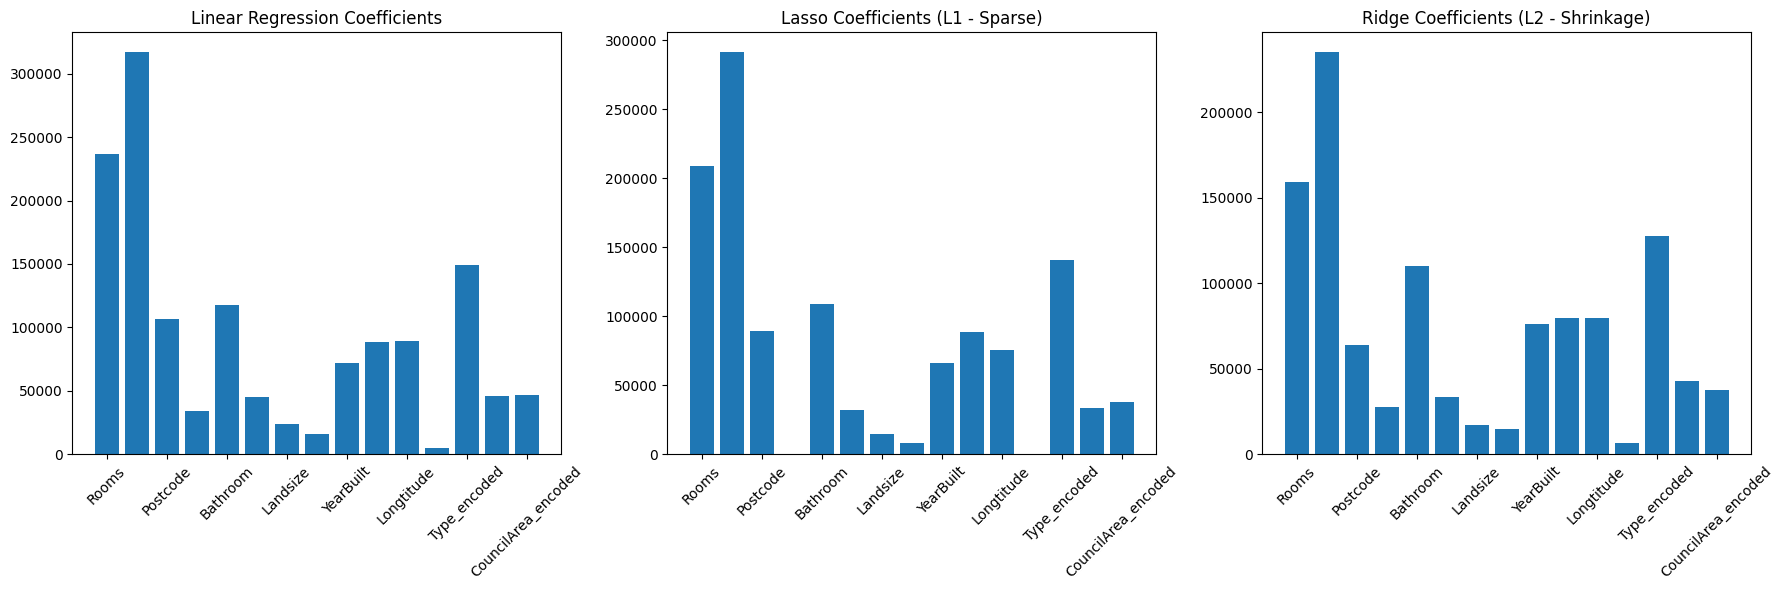

In [7]:
lr_coefs = np.abs(lr.coef_)
lasso_coefs_abs = np.abs(best_lasso.coef_)
ridge_coefs_abs = np.abs(best_ridge.coef_)

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
feature_names = X.columns

axes[0].bar(range(len(lr_coefs)), lr_coefs)
axes[0].set_title('Linear Regression Coefficients')
axes[0].set_xticks(range(0, len(feature_names), 2))
axes[0].set_xticklabels(feature_names[::2], rotation=45)

axes[1].bar(range(len(lasso_coefs_abs)), lasso_coefs_abs)
axes[1].set_title('Lasso Coefficients (L1 - Sparse)')
axes[1].set_xticks(range(0, len(feature_names), 2))
axes[1].set_xticklabels(feature_names[::2], rotation=45)

axes[2].bar(range(len(ridge_coefs_abs)), ridge_coefs_abs)
axes[2].set_title('Ridge Coefficients (L2 - Shrinkage)')
axes[2].set_xticks(range(0, len(feature_names), 2))
axes[2].set_xticklabels(feature_names[::2], rotation=45)

plt.tight_layout()
plt.savefig('output/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

##Regularization path analysis

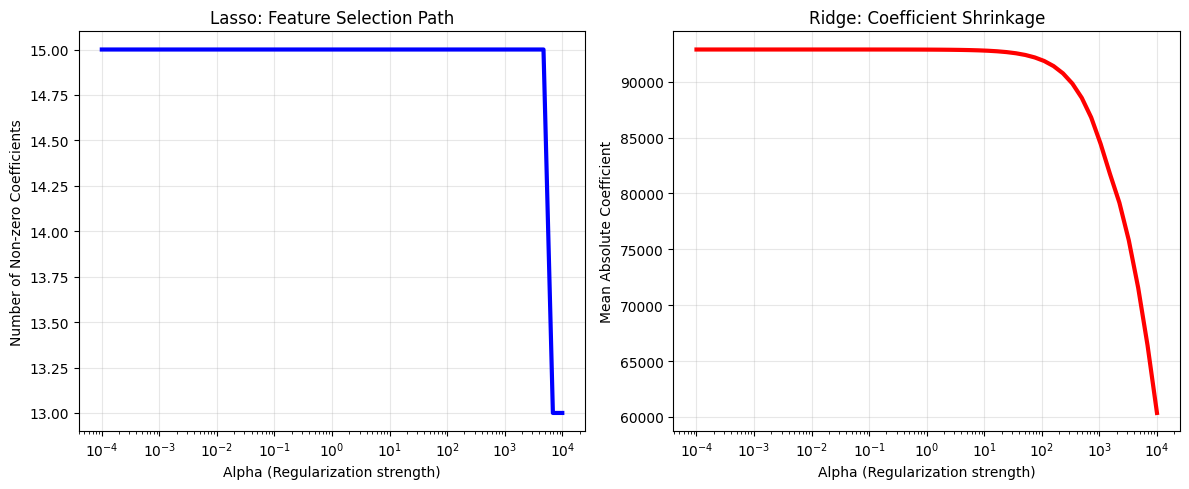

In [8]:
alphas = np.logspace(-4, 4, 50)
lasso_path = []
ridge_path = []

for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso_temp.fit(X_train_scaled, y_train)
    lasso_path.append(np.sum(lasso_temp.coef_ != 0))

    ridge_temp = Ridge(alpha=alpha, max_iter=10000, random_state=42)
    ridge_temp.fit(X_train_scaled, y_train)
    ridge_path.append(np.mean(np.abs(ridge_temp.coef_)))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(alphas, lasso_path, 'b-', linewidth=3)
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Number of Non-zero Coefficients')
plt.title('Lasso: Feature Selection Path')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(alphas, ridge_path, 'r-', linewidth=3)
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Mean Absolute Coefficient')
plt.title('Ridge: Coefficient Shrinkage')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/regularization_paths.png', dpi=300, bbox_inches='tight')
plt.show()

##Cross-validation scores for different alpha values

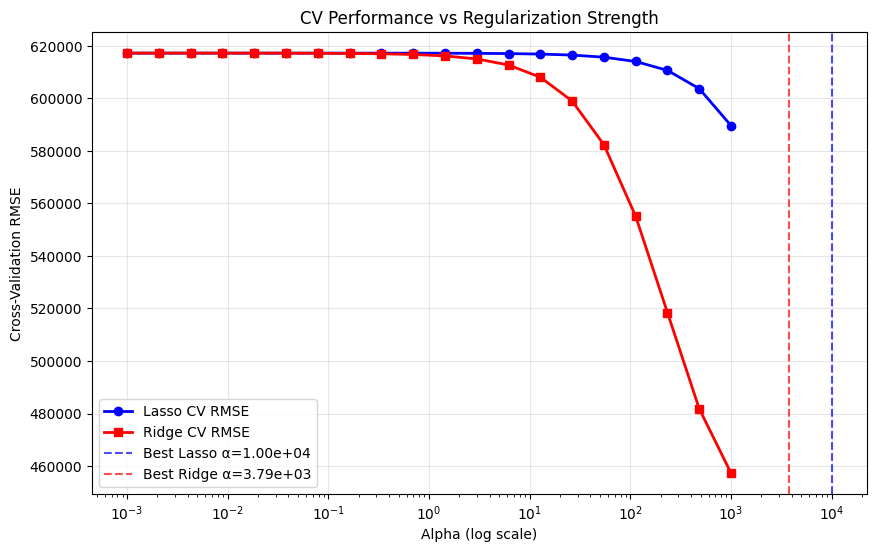

In [10]:
# Cell 10: Cross-validation scores for different alpha values
from sklearn.model_selection import cross_val_score

lasso_cv_scores = []
ridge_cv_scores = []
alphas_cv = np.logspace(-3, 3, 20)

for alpha in alphas_cv:
    lasso_temp = Lasso(alpha=alpha, max_iter=5000)
    lasso_rmse = np.sqrt(-cross_val_score(
        lasso_temp, X_train_scaled, y_train,
        cv=5, scoring='neg_mean_squared_error'
    ).mean())
    lasso_cv_scores.append(lasso_rmse)

    ridge_temp = Ridge(alpha=alpha)
    ridge_rmse = np.sqrt(-cross_val_score(
        ridge_temp, X_train_scaled, y_train,
        cv=5, scoring='neg_mean_squared_error'
    ).mean())
    ridge_cv_scores.append(ridge_rmse)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas_cv, lasso_cv_scores, 'b-o', label='Lasso CV RMSE', linewidth=2)
plt.semilogx(alphas_cv, ridge_cv_scores, 'r-s', label='Ridge CV RMSE', linewidth=2)
plt.axvline(lasso_gs.best_params_['alpha'], color='b', linestyle='--', alpha=0.7,
            label=f'Best Lasso α={lasso_gs.best_params_["alpha"]:.2e}')
plt.axvline(ridge_gs.best_params_['alpha'], color='r', linestyle='--', alpha=0.7,
            label=f'Best Ridge α={ridge_gs.best_params_["alpha"]:.2e}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validation RMSE')
plt.title('CV Performance vs Regularization Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('output/cv_alpha_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

##Summary of model performance

In [11]:
from sklearn.model_selection import cross_val_score

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge'],
    'Train R2': [
        r2_score(y_train, lr.predict(X_train_scaled)),
        r2_score(y_train, best_lasso.predict(X_train_scaled)),
        r2_score(y_train, best_ridge.predict(X_train_scaled))
    ],
    'Test R2': [
        r2_score(y_test, lr.predict(X_test_scaled)),
        r2_score(y_test, best_lasso.predict(X_test_scaled)),
        r2_score(y_test, best_ridge.predict(X_test_scaled))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, lr.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, best_lasso.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test_scaled)))
    ]
})

print(summary)
summary.to_csv('output/model_summary.csv', index=False)

               Model  Train R2   Test R2      Test RMSE
0  Linear Regression  0.531440  0.492715  465583.108558
1              Lasso  0.527471  0.496953  463634.277021
2              Ridge  0.515122  0.480784  471026.630392


##Actual ROC-AUC for binary target using price above median

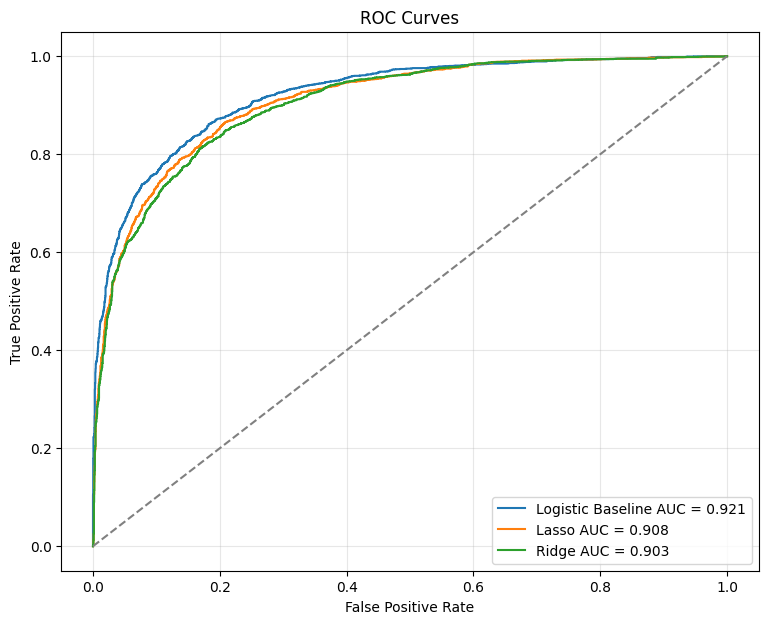

               Model       AUC
0  Logistic Baseline  0.921012
1              Lasso  0.908454
2              Ridge  0.903474


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Binary target
y_binary = (y > y.median()).astype(int)

# Train-test split again for classification-style ROC
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# Logistic regression baselines for ROC
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_b_scaled, y_train_b)
y_prob_log = log_reg.predict_proba(X_test_b_scaled)[:, 1]

# Convert Lasso/Ridge regression outputs to probability-like scores
def to_prob(scores):
    scores = np.asarray(scores)
    return 1 / (1 + np.exp(-(scores - scores.mean()) / (scores.std() + 1e-9)))

lasso_prob = to_prob(best_lasso.predict(X_test_scaled))
ridge_prob = to_prob(best_ridge.predict(X_test_scaled))

fpr_log, tpr_log, _ = roc_curve(y_test_b, y_prob_log)
fpr_lasso, tpr_lasso, _ = roc_curve((y_test > y_test.median()).astype(int), lasso_prob)
fpr_ridge, tpr_ridge, _ = roc_curve((y_test > y_test.median()).astype(int), ridge_prob)

auc_log = auc(fpr_log, tpr_log)
auc_lasso = auc(fpr_lasso, tpr_lasso)
auc_ridge = auc(fpr_ridge, tpr_ridge)

plt.figure(figsize=(9, 7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Baseline AUC = {auc_log:.3f}')
plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso AUC = {auc_lasso:.3f}')
plt.plot(fpr_ridge, tpr_ridge, label=f'Ridge AUC = {auc_ridge:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('output/roc_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

roc_df = pd.DataFrame({
    'Model': ['Logistic Baseline', 'Lasso', 'Ridge'],
    'AUC': [auc_log, auc_lasso, auc_ridge]
})
print(roc_df)
roc_df.to_csv('output/roc_auc_summary.csv', index=False)